# Modelo Multimodal: MTDE-Net (Baseline vs. Optimizado)

Este cuaderno implementa de manera secuencial el entrenamiento y comparación de **MTDE-Net**:
1. **Fase A (Baseline):** Entrenamiento con la configuración inicial por defecto (sin sintonizar).
2. **Fase B (Optimizado):** Entrenamiento con la configuración de hiperparámetros campeona encontrada mediante optimización bayesiana con Optuna y semilla fija.

Al final del cuaderno, se genera de manera automática una **tabla comparativa de métricas** lista para incluir en el reporte final de tu tesis.

In [ ]:
import sys
import random
from pathlib import Path

# Añadir el directorio raíz al path de Python para permitir importaciones correctas
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

from src.models.mtde_net import MTDE_Net
from src.loaders.mtde_net_loader import MultimodalThermalDataset
from src.utils import SqrtScaledMSELoss, eval_mtde_net_metrics, split_by_sequence, plot_learning_curves, plot_prediction_calibration, plot_error_by_time_window

### 1. Semilla Global y Reproducibilidad

In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

### 2. Carga del Dataset y Partición Estricta (Compartida)

In [3]:
dev = "cuda" if torch.cuda.is_available() else "cpu"
time_scale = 30.0

train_ds_full = MultimodalThermalDataset(
    metadata_csv="../processed_data/metadata_train.csv", 
    is_train=True, 
    min_time_s=0.0,
    time_scale=time_scale
)
val_ds_full = MultimodalThermalDataset(
    metadata_csv="../processed_data/metadata_train.csv", 
    is_train=False, 
    min_time_s=0.0,
    time_scale=time_scale
)

# Forzar el mapeo de ruta para entorno notebook
train_ds_full.root = Path("../processed_data")
val_ds_full.root = Path("../processed_data")

t_idx, v_idx = split_by_sequence(train_ds_full.df)

print(f"Dataset cargado exitosamente. Particiones: {len(t_idx)} train / {len(v_idx)} val")

Dataset cargado exitosamente. Particiones: 1111 train / 329 val


--- 
## FASE A: Entrenamiento del Modelo Baseline (Sin Tunear)

Esta sección entrena el modelo con los hiperparámetros iniciales por defecto.

In [4]:
BASELINE_CONFIG = {
    "epochs": 120,
    "patience": 15,
    "min_delta": 1.0,
    "batch_size": 16,
    "lr": 0.0005,
    "weight_decay": 0.0005,
}

set_seed(42)

# 2. Dataloaders específicos para Baseline
train_loader_base = DataLoader(Subset(train_ds_full, t_idx), batch_size=BASELINE_CONFIG["batch_size"], shuffle=True)
val_loader_base = DataLoader(Subset(val_ds_full, v_idx), batch_size=BASELINE_CONFIG["batch_size"])
train_eval_loader_base = DataLoader(Subset(train_ds_full, t_idx), batch_size=BASELINE_CONFIG["batch_size"])

# 3. Inicializar Modelo Baseline
model_base = MTDE_Net(dropout=0.2).to(dev)
crit = SqrtScaledMSELoss(scale=None)
opt = torch.optim.AdamW(model_base.parameters(), lr=BASELINE_CONFIG["lr"], weight_decay=BASELINE_CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[30, 60, 80], gamma=0.8)

print(f"Iniciando entrenamiento Baseline... Parámetros: {sum(p.numel() for p in model_base.parameters()):,}")

# 4. Ciclo de Entrenamiento
best_mae_base = float("inf")
no_imp = 0
history_base = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}

for ep in range(1, BASELINE_CONFIG["epochs"] + 1):
    model_base.train()
    train_loss, n = 0.0, 0
    for x_img, x_tab, y in train_loader_base:
        x_img, x_tab, y = x_img.to(dev), x_tab.to(dev), y.to(dev)
        opt.zero_grad(set_to_none=True)
        loss = crit(model_base(x_img, x_tab), y)
        loss.backward()
        opt.step()
        train_loss += loss.item() * x_img.size(0)
        n += x_img.size(0)

    scheduler.step()
    
    # Pérdida de validación para el historial
    model_base.eval()
    val_loss = 0.0
    val_n = 0
    with torch.no_grad():
        for val_x_img, val_x_tab, val_y in val_loader_base:
            val_x_img, val_x_tab, val_y = val_x_img.to(dev), val_x_tab.to(dev), val_y.to(dev)
            loss = crit(model_base(val_x_img, val_x_tab), val_y)
            val_loss += loss.item() * val_x_img.size(0)
            val_n += val_x_img.size(0)
    val_loss /= val_n

    # Evaluar métricas unificadas en segundos reales
    val_m = eval_mtde_net_metrics(model_base, val_loader_base, dev, scale=time_scale)
    train_m = eval_mtde_net_metrics(model_base, train_eval_loader_base, dev, scale=time_scale)
    
    v_mae = val_m["mae"]
    is_best = v_mae < best_mae_base - BASELINE_CONFIG["min_delta"]
    if is_best: 
        best_mae_base, no_imp = v_mae, 0
        torch.save(model_base.state_dict(), "../MTDE_Net_baseline.pt")
        baseline_metrics = val_m
    else: 
        no_imp += 1
        
    # Guardar métricas en el historial
    history_base["train_loss"].append(train_loss / n)
    history_base["val_loss"].append(val_loss)
    history_base["train_mae"].append(train_m["mae"])
    history_base["val_mae"].append(v_mae)
    
    print(f"Ep {ep:03d} | Loss: {train_loss/n:.4f} | TrMAE: {train_m['mae']:5.2f}s | ValMAE: {v_mae:5.2f}s | "
          f"RMSE: {val_m['rmse']:5.2f}s | R2: {val_m['r2']:.4f} | MAPE: {val_m['mape']:5.2f}% | "
          f"Acc60: {val_m['acc60']:.2f}% | Acc120: {val_m['acc120']:.2f}% {'*' if is_best else ''}")
    
    if no_imp >= BASELINE_CONFIG["patience"]:
        print(f"Early stop alcanzado. Mejor Val MAE Baseline: {best_mae_base:.2f}s")
        break

Iniciando entrenamiento Baseline... Parámetros: 1,325,421
Ep 001 | Loss: 1.4660 | TrMAE: 107.75s | ValMAE: 127.23s | RMSE: 172.82s | R2: -0.0988 | MAPE: 70.00% | Acc60: 39.51% | Acc120: 60.49% *
Ep 002 | Loss: 0.7058 | TrMAE: 85.41s | ValMAE: 93.78s | RMSE: 140.56s | R2: 0.2732 | MAPE: 53.73% | Acc60: 56.84% | Acc120: 71.73% *
Ep 003 | Loss: 0.5044 | TrMAE: 135.28s | ValMAE: 151.65s | RMSE: 190.91s | R2: -0.3409 | MAPE: 84.22% | Acc60: 25.84% | Acc120: 44.07% 
Ep 004 | Loss: 0.3772 | TrMAE: 55.87s | ValMAE: 60.20s | RMSE: 78.01s | R2: 0.7761 | MAPE: 48.02% | Acc60: 60.18% | Acc120: 89.36% *
Ep 005 | Loss: 0.3280 | TrMAE: 84.47s | ValMAE: 100.40s | RMSE: 136.48s | R2: 0.3147 | MAPE: 61.19% | Acc60: 43.16% | Acc120: 70.52% 
Ep 006 | Loss: 0.2768 | TrMAE: 52.16s | ValMAE: 54.73s | RMSE: 68.32s | R2: 0.8283 | MAPE: 48.03% | Acc60: 63.53% | Acc120: 92.40% *
Ep 007 | Loss: 0.2067 | TrMAE: 34.02s | ValMAE: 31.76s | RMSE: 45.77s | R2: 0.9229 | MAPE: 24.34% | Acc60: 85.11% | Acc120: 96.35% *
Ep

--- 
## FASE B: Entrenamiento del Modelo Optimizado (Optuna Champion)

Esta sección entrena el modelo con los hiperparámetros óptimos encontrados en tu estudio determinista con Optuna.

In [5]:
# 1. Hiperparámetros Campeones Encontrados
OPTIMIZED_CONFIG = {
    "epochs": 120,
    "patience": 15,
    "min_delta": 1.0,
    'lr': 0.0008180975206277762, 
    'weight_decay': 0.00012881632695032252, 
    'batch_size': 32, 
    'dropout': 0.10206052682964781
}

set_seed(42)

# 2. Dataloaders específicos para Optimizado
train_loader_opt = DataLoader(Subset(train_ds_full, t_idx), batch_size=OPTIMIZED_CONFIG["batch_size"], shuffle=True)
val_loader_opt = DataLoader(Subset(val_ds_full, v_idx), batch_size=OPTIMIZED_CONFIG["batch_size"])
train_eval_loader_opt = DataLoader(Subset(train_ds_full, t_idx), batch_size=OPTIMIZED_CONFIG["batch_size"])

# 3. Inicializar Modelo Optimizado
model_opt = MTDE_Net(dropout=OPTIMIZED_CONFIG["dropout"]).to(dev)
crit = SqrtScaledMSELoss(scale=None)
opt = torch.optim.AdamW(model_opt.parameters(), lr=OPTIMIZED_CONFIG["lr"], weight_decay=OPTIMIZED_CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[30, 60, 80], gamma=0.8)

print(f"Iniciando entrenamiento Optimizado... Parámetros: {sum(p.numel() for p in model_opt.parameters()):,}")

# 4. Ciclo de Entrenamiento
best_mae_opt = float("inf")
no_imp = 0
history_opt = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}

for ep in range(1, OPTIMIZED_CONFIG["epochs"] + 1):
    model_opt.train()
    train_loss, n = 0.0, 0
    for x_img, x_tab, y in train_loader_opt:
        x_img, x_tab, y = x_img.to(dev), x_tab.to(dev), y.to(dev)
        opt.zero_grad(set_to_none=True)
        loss = crit(model_opt(x_img, x_tab), y)
        loss.backward()
        opt.step()
        train_loss += loss.item() * x_img.size(0)
        n += x_img.size(0)

    scheduler.step()
    
    # Pérdida de validación para el historial
    model_opt.eval()
    val_loss = 0.0
    val_n = 0
    with torch.no_grad():
        for val_x_img, val_x_tab, val_y in val_loader_opt:
            val_x_img, val_x_tab, val_y = val_x_img.to(dev), val_x_tab.to(dev), val_y.to(dev)
            loss = crit(model_opt(val_x_img, val_x_tab), val_y)
            val_loss += loss.item() * val_x_img.size(0)
            val_n += val_x_img.size(0)
    val_loss /= val_n

    # Evaluar métricas unificadas en segundos reales
    val_m = eval_mtde_net_metrics(model_opt, val_loader_opt, dev, scale=time_scale)
    train_m = eval_mtde_net_metrics(model_opt, train_eval_loader_opt, dev, scale=time_scale)
    
    v_mae = val_m["mae"]
    is_best = v_mae < best_mae_opt - OPTIMIZED_CONFIG["min_delta"]
    if is_best: 
        best_mae_opt, no_imp = v_mae, 0
        torch.save(model_opt.state_dict(), "../MTDE_Net_best.pt")
        optimized_metrics = val_m
    else: 
        no_imp += 1
        
    # Guardar métricas en el historial
    history_opt["train_loss"].append(train_loss / n)
    history_opt["val_loss"].append(val_loss)
    history_opt["train_mae"].append(train_m["mae"])
    history_opt["val_mae"].append(v_mae)
    
    print(f"Ep {ep:03d} | Loss: {train_loss/n:.4f} | TrMAE: {train_m['mae']:5.2f}s | ValMAE: {v_mae:5.2f}s | "
          f"RMSE: {val_m['rmse']:5.2f}s | R2: {val_m['r2']:.4f} | MAPE: {val_m['mape']:5.2f}% | "
          f"Acc60: {val_m['acc60']:.2f}% | Acc120: {val_m['acc120']:.2f}% {'*' if is_best else ''}")
    
    if no_imp >= OPTIMIZED_CONFIG["patience"]:
        print(f"Early stop alcanzado. Mejor Val MAE Optimizado: {best_mae_opt:.2f}s")
        break

Iniciando entrenamiento Optimizado... Parámetros: 1,325,421
Ep 001 | Loss: 1.5682 | TrMAE: 80.82s | ValMAE: 73.44s | RMSE: 110.80s | R2: 0.5484 | MAPE: 77.58% | Acc60: 62.31% | Acc120: 82.07% *
Ep 002 | Loss: 0.7737 | TrMAE: 72.14s | ValMAE: 72.07s | RMSE: 101.22s | R2: 0.6231 | MAPE: 53.42% | Acc60: 57.75% | Acc120: 83.89% *
Ep 003 | Loss: 0.4176 | TrMAE: 153.93s | ValMAE: 155.57s | RMSE: 194.12s | R2: -0.3862 | MAPE: 85.93% | Acc60: 25.53% | Acc120: 45.29% 
Ep 004 | Loss: 0.2962 | TrMAE: 68.73s | ValMAE: 79.68s | RMSE: 108.65s | R2: 0.5657 | MAPE: 50.45% | Acc60: 55.62% | Acc120: 76.90% 
Ep 005 | Loss: 0.2471 | TrMAE: 39.95s | ValMAE: 44.92s | RMSE: 63.39s | R2: 0.8522 | MAPE: 34.64% | Acc60: 74.16% | Acc120: 92.40% *
Ep 006 | Loss: 0.1890 | TrMAE: 61.94s | ValMAE: 63.99s | RMSE: 85.28s | R2: 0.7324 | MAPE: 46.89% | Acc60: 59.57% | Acc120: 85.11% 
Ep 007 | Loss: 0.1612 | TrMAE: 38.52s | ValMAE: 51.16s | RMSE: 73.85s | R2: 0.7994 | MAPE: 33.42% | Acc60: 69.60% | Acc120: 89.97% 
Ep 008

--- 
## 3. Tabla Comparativa de Resultados Finales

Esta celda autogenera una tabla markdown limpia comparando ambos escenarios listos para exportar.

In [6]:
comparative_data = {
    "Métrica": ["MAE (Error Absoluto Medio)", "RMSE (Error Cuadrático Medio)", "R² (Coeficiente de Det.)", "MAPE (Error Porcentual)", "Acc@60s (Exactitud 1 min)", "Acc@120s (Exactitud 2 min)"],
    "Baseline (Default)": [
        f"{baseline_metrics['mae']:.2f} s",
        f"{baseline_metrics['rmse']:.2f} s",
        f"{baseline_metrics['r2']:.4f}",
        f"{baseline_metrics['mape']:.2f} %",
        f"{baseline_metrics['acc60']:.2f} %",
        f"{baseline_metrics['acc120']:.2f} %"
    ],
    "Optimizado (Optuna)": [
        f"{optimized_metrics['mae']:.2f} s",
        f"{optimized_metrics['rmse']:.2f} s",
        f"{optimized_metrics['r2']:.4f}",
        f"{optimized_metrics['mape']:.2f} %",
        f"{optimized_metrics['acc60']:.2f} %",
        f"{optimized_metrics['acc120']:.2f} %"
    ]
}

df_comparison = pd.DataFrame(comparative_data)
from IPython.display import display, Markdown
display(Markdown("### Tabla Comparativa de MTDE-Net para Tesis"))
display(df_comparison)

### Tabla Comparativa de MTDE-Net para Tesis

,Métrica,Baseline (Default),Optimizado (Optuna)
0,MAE (Error Absoluto Medio),24.56 s,22.02 s
1,RMSE (Error Cuadrático Medio),35.86 s,31.02 s
2,R² (Coeficiente de Det.),0.9527,0.9646
3,MAPE (Error Porcentual),24.72 %,19.17 %
4,Acc@60s (Exactitud 1 min),89.36 %,93.31 %
5,Acc@120s (Exactitud 2 min),99.39 %,99.70 %


### 5. Visualización del Modelo Optimizado (MTDE-Net Champion)

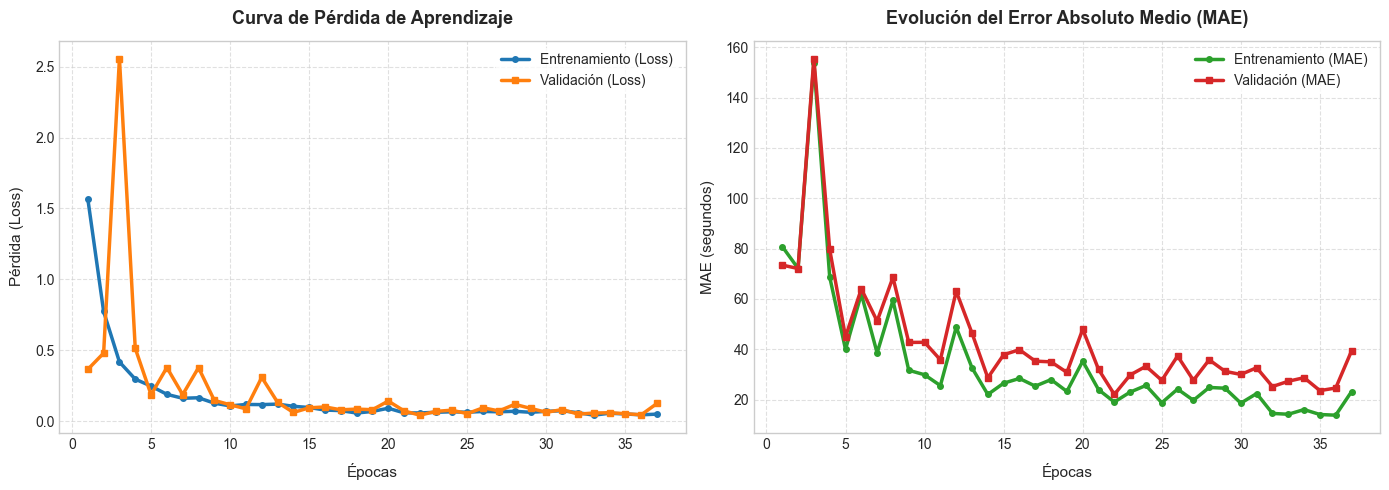

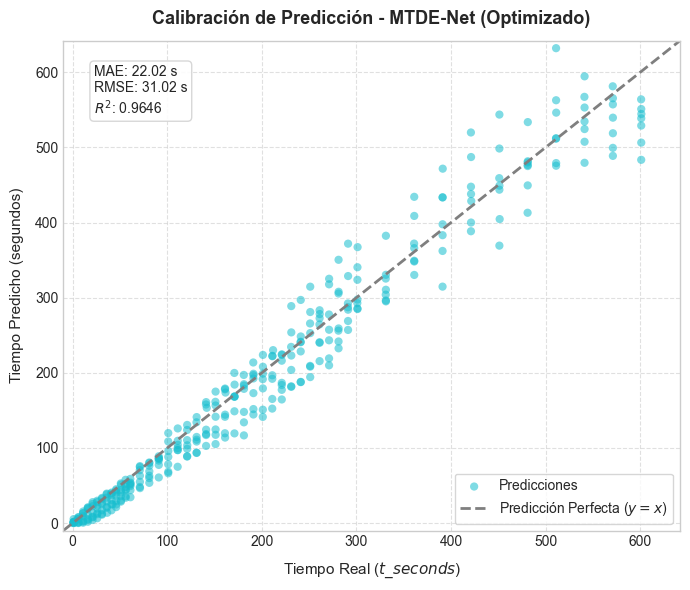

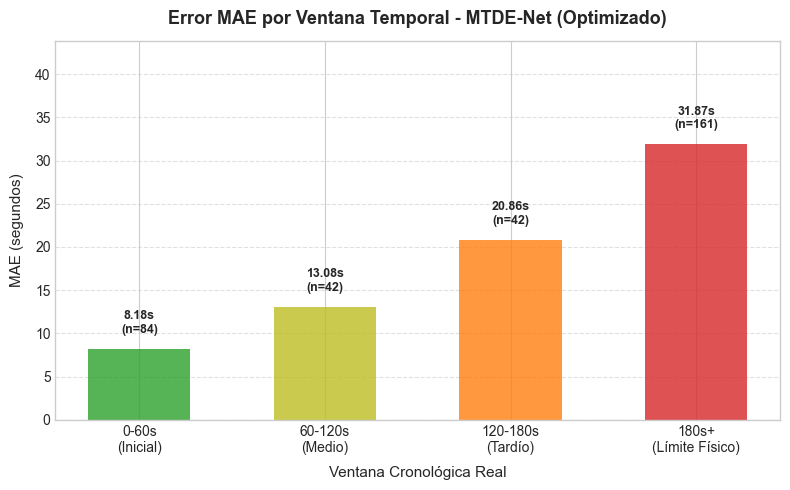

In [7]:
# 1. Graficar Curvas de Aprendizaje (Optimizado)
plot_learning_curves(history_opt)

# 2. Cargar el mejor modelo Optimizado guardado
model_opt.load_state_dict(torch.load("../MTDE_Net_best.pt"))
model_opt.eval()

# 3. Recolectar predicciones desescaladas a segundos reales
y_true_list = []
y_pred_list = []
with torch.no_grad():
    for x_img, x_tab, y in val_loader_opt:
        x_img, x_tab, y = x_img.to(dev), x_tab.to(dev), y.to(dev)
        preds = model_opt(x_img, x_tab)
        y_true_list.extend((y.cpu().numpy() * time_scale).tolist())
        y_pred_list.extend((preds.cpu().numpy() * time_scale).tolist())

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)

# 4. Graficar Calibración y Distribución del Error
plot_prediction_calibration(y_true, y_pred, model_name="MTDE-Net (Optimizado)")
plot_error_by_time_window(y_true, y_pred, model_name="MTDE-Net (Optimizado)")